In [10]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns

## 相关文件设置

In [11]:
mc_dir = "/pool1/lhcb/zhicaiz/mc/2024/HNL_Wmumuqq/ntuple/ntuple_20260228/"
data_dir = "/pool1/lhcb/zhicaiz/data/Collision24/ntuple_HNL_Wmumuqq/"
mc_file = "42912010_5GeVCtau0ps_options_20260228_111712_skim.root"
data_file = "data_MagUp_Sprucing24r1_all_disk_options_20260228_011229_skim.root"

mc_path = os.path.join(mc_dir, mc_file)
data_path = os.path.join(data_dir, data_file)
direction = "myTupleOS1J"

branch_file = "./csv/branches_to_train.csv"
branches_to_load = pd.read_csv(branch_file)["Branch"].tolist()

print("Branches to load:", branches_to_load)

Branches to load: ['Mu_POSITION_STATEAT_LastMeasurement_Z', 'Mu_PT', 'Mu_HCALEOP', 'Mu_ELECTRONSHOWEREOP', 'Mu_BREMTRACKBASEDENERGY', 'Mu_PROBNN_PI', 'Mu_PROBNN_GHOST', 'Mu_PROBNN_MU', 'MuNuR_OWNPVIP', 'MuNuR_MINIP', 'MuNuR_POSITION_STATEAT_LastMeasurement_Z', 'MuNuR_E', 'MuNuR_P', 'MuNuR_PZ', 'nTTracks', 'nFTClusters']


In [12]:
def load_root(root_file, branches, direction = "myTupleOS1J", type="mc"):
    """
    从 ROOT 文件加载数据到 pandas DataFrame。
    MC 文件标记为 1,真实数据标记为 0。

    参数：
    - root_file: ROOT 文件的路径。
    - branches: 要加载的分支名列表。
    - direction: ROOT 文件中树的路径（默认是 "myTupleOS1J"）。
    - type: "mc" 表示蒙特卡洛数据，"data" 表示真实数据（默认是 "mc"）。

    返回：
    - 一个包含加载数据并附加 "label" 列的 pandas DataFrame。
    """
    with uproot.open(root_file) as f:
        treepath = f"{direction}/DecayTree"
        tree = f[treepath]
        df = tree.arrays(branches, library="pd")
        df = df.fillna(0)
        df["label"] = 1 if type == "mc" else 0
    return df

## 构建数据

In [13]:
mc_set = load_root(mc_path, branches_to_load, direction, type="mc")
data_set = load_root(data_path, branches_to_load, direction, type="data")

# 取data_set的前10000行进行测试
data_set = data_set.head(10000)

print("MC data shape:", mc_set.shape)
print("Data data shape:", data_set.shape)
total_data = pd.concat([mc_set, data_set], ignore_index=True)
print("Total data shape:", total_data.shape)

X = total_data.drop(columns=["label"])
y = total_data["label"]
print("Feature data shape:", X.shape)
print("Label data shape:", y.shape)

print("-"*50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, shuffle=True)
print("Training feature shape:", X_train.shape)
print("Training label shape:", y_train.shape)
print("Testing feature shape:", X_test.shape)
print("Testing label shape:", y_test.shape)

MC data shape: (4921, 17)
Data data shape: (10000, 17)
Total data shape: (14921, 17)
Feature data shape: (14921, 16)
Label data shape: (14921,)
--------------------------------------------------
Training feature shape: (7460, 16)
Training label shape: (7460,)
Testing feature shape: (7461, 16)
Testing label shape: (7461,)


## 构建GBDT模型

In [14]:
gbdt_params = {
    "n_estimators": 50,
    "learning_rate": 0.1,
    "max_depth": 3,
    "random_state": 42,
    "loss": 'log_loss',
    "verbose": 1,
    # --- 防止过拟合/特征主导的关键参数 ---
    "max_features": "sqrt",  # 每次分裂只考虑 sqrt(n_features) 个特征，防止单一强特征主导
    "subsample": 0.8,        # 随机采样 80% 的数据训练每棵树（随机梯度提升），增加鲁棒性
    "min_samples_leaf": 20,  # 叶子节点最少需要的样本数，避免对个别离群点过拟合
}

gbdt = GradientBoostingClassifier(**gbdt_params)

In [15]:
# 训练并评估模型
import joblib
gbdt.fit(X_train, y_train)
joblib.dump(gbdt, "gbdt_model.pkl")  # 保存模型到文件

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.1172           0.1469            0.37s
         2           0.9781           0.1634            0.35s
         3           0.8707           0.0860            0.35s
         4           0.7943           0.0863            0.34s
         5           0.7105           0.0869            0.33s
         6           0.6514           0.0512            0.33s
         7           0.5858           0.0637            0.32s
         8           0.5297           0.0614            0.31s
         9           0.4857           0.0446            0.31s
        10           0.4320           0.0427            0.30s
        20           0.1796           0.0061            0.22s
        30           0.0904           0.0103            0.15s
        40           0.0480           0.0041            0.07s
        50           0.0251          -0.0022            0.00s


['gbdt_model.pkl']

In [16]:
y_pred = gbdt.predict(X_test)
y_proba = gbdt.predict_proba(X_test) if hasattr(gbdt, 'predict_proba') else None

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)

Accuracy: 0.9991958182549256
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4973
           1       1.00      1.00      1.00      2488

    accuracy                           1.00      7461
   macro avg       1.00      1.00      1.00      7461
weighted avg       1.00      1.00      1.00      7461

Confusion matrix:
 [[4968    5]
 [   1 2487]]


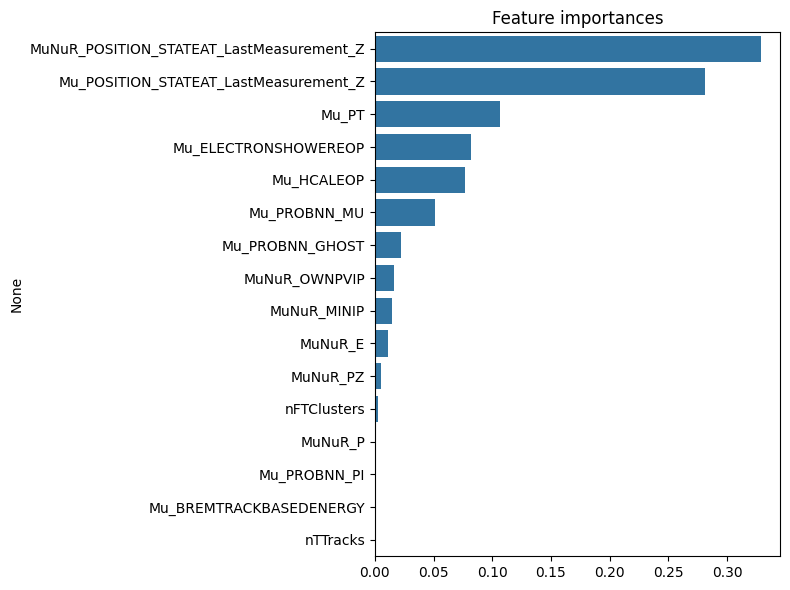

In [17]:
# 特征重要性（可选）
feat_importances = pd.Series(gbdt.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=feat_importances.values[:20], y=feat_importances.index[:20])
plt.title('Feature importances')
plt.tight_layout()
plt.show()

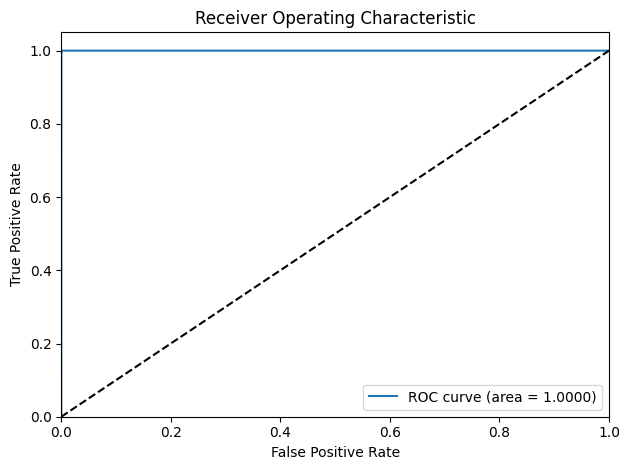

In [18]:
## 绘制roc曲线（可选）
from sklearn.metrics import roc_curve, auc
if y_proba is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
    roc_auc = auc(fpr, tpr)
    # plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()